# 1. Generate Data

X0 shape: (2000, 2)
X1 shape: (2000, 2)
Labels shape: (2000, 1)


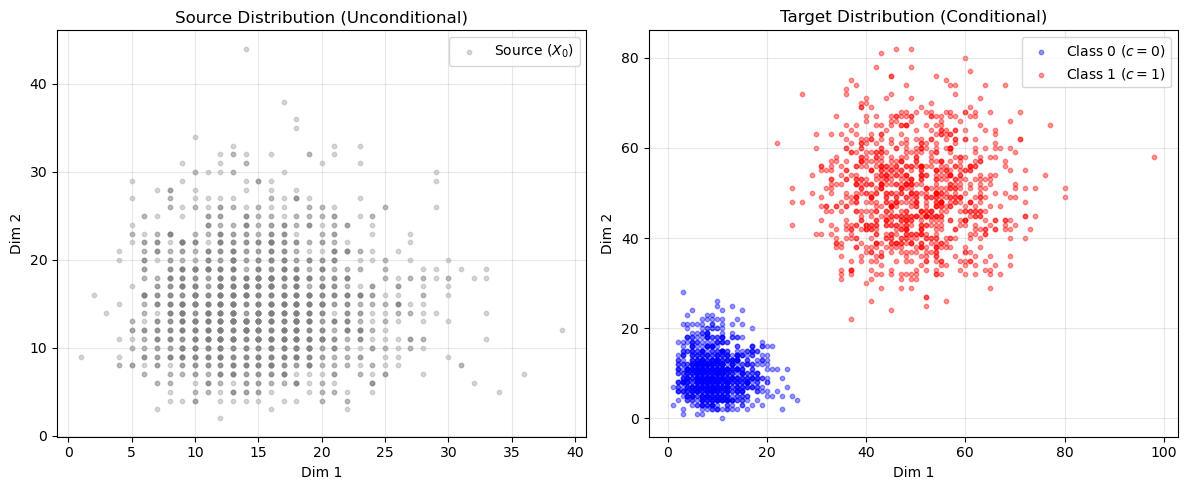

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)

# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

def simulate_conditional_data(N=2000):
    """
    Simulates source (X0) and conditional target (X1) counting data.
    
    Returns:
        X0: Source samples (unconditional)
        X1: Target samples (conditional mixture)
        c:  Class labels (0 or 1)
    """
    # 1. Generate Class Labels c ~ Bernoulli(0.5)
    # c is shape (N, 1) to make broadcasting easier later
    c = (np.random.rand(N, 1) < 0.5).astype(int) 
    
    # 2. Source X0 (Unconditional / Prior)
    # 2D independent Poisson data essentially serving as our "noise"
    # Gamma params for source: shape=15, scale=1.0
    k_src    = np.array([15.0, 15.0])
    rate_src = np.array([1.0,  1.0])
    
    # Sample intensities lambda0
    lam0 = np.random.gamma(shape=k_src, scale=1.0/rate_src, size=(N, 2))
    X0   = np.random.poisson(lam0)

    # 3. Target X1 (Conditional on c)
    # We define two different distributions for the two classes.
    # Class 0: Lower counts, centered around ~10
    # Class 1: Higher counts, centered around ~50
    
    # Params: [Class 0 params, Class 1 params]
    # Dimensions: 2D data
    
    # Class 0: Shape=[10, 10], Rate=[1, 1] -> Mean = 10
    # Class 1: Shape=[50, 50], Rate=[1, 1] -> Mean = 50
    
    k_target_0 = np.array([10.0, 10.0])
    k_target_1 = np.array([50.0, 50.0])
    
    rate_target = 1.0 # Keep rate simple
    
    # Select parameters based on label c
    # If c=0, use k_target_0; if c=1, use k_target_1
    k_selected = k_target_0 * (1 - c) + k_target_1 * c
    
    # Sample intensities lambda1 based on the selected k
    lam1 = np.random.gamma(shape=k_selected, scale=1.0/rate_target)
    X1   = np.random.poisson(lam1)
    
    return X0, X1, c

# --- Run Simulation and Visualize ---

X0, X1, c = simulate_conditional_data()

# Convert to tensor for later use
X0_torch = torch.tensor(X0, dtype=torch.float32)
X1_torch = torch.tensor(X1, dtype=torch.float32)
c_torch  = torch.tensor(c,  dtype=torch.float32)

print(f"X0 shape: {X0.shape}")
print(f"X1 shape: {X1.shape}")
print(f"Labels shape: {c.shape}")

# Plotting
plt.figure(figsize=(12, 5))

# Plot Source
plt.subplot(1, 2, 1)
plt.scatter(X0[:, 0], X0[:, 1], c='gray', alpha=0.3, s=10, label='Source ($X_0$)')
plt.title("Source Distribution (Unconditional)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.legend()
plt.grid(True, alpha=0.3)

# Plot Conditional Target
plt.subplot(1, 2, 2)
# Extract indices
idx0 = (c.flatten() == 0)
idx1 = (c.flatten() == 1)

plt.scatter(X1[idx0, 0], X1[idx0, 1], c='blue', alpha=0.4, s=10, label='Class 0 ($c=0$)')
plt.scatter(X1[idx1, 0], X1[idx1, 1], c='red',  alpha=0.4, s=10, label='Class 1 ($c=1$)')
plt.title("Target Distribution (Conditional)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 2. conditional MLP

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConditionalMLP(nn.Module):
    """
    MLP that takes x, t, and a class label c.
    Includes an embedding layer for the class condition.
    """
    def __init__(self, dim, out_dim=None, w=64, num_classes=3, cond_dim=16):
        """
        Args:
            dim: Input data dimension (e.g., 2 for 2D data)
            out_dim: Output dimension (velocity/rate)
            w: Hidden layer width
            num_classes: Number of classes. 
                         (e.g., 2 classes + 1 null token for CFG = 3)
            cond_dim: Dimension of the class embedding
        """
        super().__init__()
        if out_dim is None:
            out_dim = dim
            
        # Embedding layer for class labels (including null token)
        self.class_emb = nn.Embedding(num_classes, cond_dim)
        
        # Input: Data (dim) + Time (1) + Condition Embedding (cond_dim)
        input_size = dim + 1 + cond_dim
        
        self.net = nn.Sequential(
            nn.Linear(input_size, w),
            nn.SELU(),
            nn.Linear(w, w),
            nn.SELU(),
            nn.Linear(w, w),
            nn.SELU(),
            nn.Linear(w, out_dim),
        )

    def forward(self, x, t, c):
        """
        Args:
            x: [B, dim] float tensor (noisy data)
            t: [B, 1] float tensor (time)
            c: [B] long/int tensor (class labels)
        """
        # 1. Embed the class label
        c_emb = self.class_emb(c) # [B, cond_dim]
        
        # 2. Concatenate inputs: [x, t, c_emb]
        # x is [B, dim], t is [B, 1], c_emb is [B, cond_dim]
        net_in = torch.cat([x, t, c_emb], dim=1)
        
        # 3. Pass through MLP
        return self.net(net_in)

class MLP_rate_conditional(nn.Module):
    """
    Wrapper to ensure output is positive (Softplus), used for rate prediction.
    Accepts conditional inputs.
    """
    def __init__(self, base_mlp):
        super().__init__()
        self.base = base_mlp
        
    def forward(self, x, t, c):
        return F.softplus(self.base(x, t, c))

# 3. Training

In [13]:
import numpy as np
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt

In [22]:
def sample_xt(x0, x1, t):
    """
    Samples intermediate state xt given x0, x1 and time t 
    using the binomial path logic.
    """
    with torch.no_grad():
        diff = x1 - x0
        sign = torch.sign(diff)
        n    = diff.abs()

        t_full = t.expand_as(n)
        b = torch.binomial(n.float(), t_full)
        return x0 + sign * b.to(x0.dtype)

def sample_rt(xt, x1, t, eps_t):
    """
    Calculates the 'ground truth' un-normalized rates for loss computation.
    """
    with torch.no_grad():
        idx_b = (x1 > xt).to(torch.float32) # birth
        idx_d = (xt > x1).to(torch.float32) # death
        idx_0 = (xt <= 0).to(torch.float32) # boundary

        # Avoid division by zero with eps_t
        denom = (1.0 - t + eps_t)
        
        lambda_star = idx_b * (x1 - xt) / denom        
        mu_star     = idx_d * (xt - x1) / denom * (1 - idx_0)
        
        rates_star = torch.cat([lambda_star, mu_star], dim=1)
        return rates_star, idx_0

def model_forward(nets, xt, t, c, d, idx_0):
    """
    Forward pass adapted for the Conditional Model.
    nets: instance of MLP_rate_conditional
    """
    # Helper to split output into birth (lambda) and death (beta/mu) parameters
    # The network predicts [lambda, beta]
    out = nets(xt, t, c) 
    
    lambda_theta = out[:, :d]
    beta_theta   = out[:, d:]
    
    # Calculate mu (death rate) = x * beta
    mu_theta = (xt * beta_theta) * (1.0 - idx_0)
    
    rates_theta = torch.cat([lambda_theta, mu_theta], dim=1)
    return rates_theta

def model_loss(rates_theta, rates_star, loss_mode='poisson', eps_log=1e-8):
    if loss_mode == "l2":
        loss = ((rates_theta - rates_star)**2).sum(dim=1).mean()
    else:
        # Poisson deviance / KL-like loss
        u = rates_star
        v = rates_theta
        loss = (v - u * torch.log(v + eps_log)).sum(1).mean()
    return loss

# --- 2. Data Simulation (Conditional) ---

def get_data(N=2000):
    np.random.seed(42)
    # 1. Labels
    c = (np.random.rand(N) < 0.5).astype(int)
    
    # 2. Source X0 (Unconditional)
    k_src    = np.array([15.0, 15.0])
    X0 = np.random.poisson(np.random.gamma(shape=k_src, scale=1.0, size=(N, 2)))

    # 3. Target X1 (Conditional)
    # Class 0: Mean 10, Class 1: Mean 50
    k0 = np.array([10.0, 10.0])
    k1 = np.array([50.0, 50.0])
    
    # Select k based on c
    # c is (N,), need (N,2) for broadcasting
    c_exp = c[:, None] 
    k_sel = k0 * (1 - c_exp) + k1 * c_exp
    
    X1 = np.random.poisson(np.random.gamma(shape=k_sel, scale=1.0))
    
    return torch.tensor(X0).float(), torch.tensor(X1).float(), torch.tensor(c).long()

# --- 3. Training Loop ---

def train():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Settings
    d = 2
    batch_size = 256
    num_epochs = 10000 # Reduced for demo; increase for better results
    lr = 1e-3
    eps_t = 1e-4
    loss_mode = 'poisson'
    
    # CFG Settings
    null_class = 2  # 0, 1 are real classes. 2 is null.
    cfg_p_uncond = 0.1 # 10% probability to drop condition
    
    # Data
    X0, X1, C_labels = get_data(N=2000)
    X0, X1, C_labels = X0.to(device), X1.to(device), C_labels.to(device)
    N = X0.shape[0]
    steps_per_epoch = (N + batch_size - 1) // batch_size

    # Model
    # dim=2, out_dim=4 (lambda1, lambda2, beta1, beta2), num_classes=3 (0,1,null)
    net_base = ConditionalMLP(dim=d, out_dim=2*d, w=64, num_classes=3).to(device)
    model = MLP_rate_conditional(net_base)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    # Loop
    losses = []
    
    print("Starting Training...")
    for epoch in tqdm(range(num_epochs)):
        epoch_loss = 0
        
        # Shuffle
        perm = torch.randperm(N)
        X0 = X0[perm]
        X1 = X1[perm]
        C_labels = C_labels[perm]
        
        for i in range(0, N, batch_size):
            # Batch data
            x0_batch = X0[i:i+batch_size]
            x1_batch = X1[i:i+batch_size]
            c_batch  = C_labels[i:i+batch_size]
            
            curr_batch_size = x0_batch.shape[0]
            
            # Sample time t
            t = torch.rand(curr_batch_size, 1, device=device) * (1 - 2*eps_t) + eps_t
            
            # Sample xt
            xt = sample_xt(x0_batch, x1_batch, t)
            
            # Sample ground truth rates
            rates_star, idx_0 = sample_rt(xt, x1_batch, t, eps_t)
            
            # --- CFG Dropout Logic ---
            # Create a mask for dropout [B]
            # 1 = drop (use null), 0 = keep (use real label)
            drop_mask = (torch.rand(curr_batch_size, device=device) < cfg_p_uncond)
            
            # Prepare input condition: if drop, use null_class (2), else use c
            c_in = c_batch.clone()
            c_in[drop_mask] = null_class
            
            # Model Forward
            rates_theta = model_forward(model, xt, t, c_in, d, idx_0)
            
            # Loss
            loss = model_loss(rates_theta, rates_star, loss_mode=loss_mode)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            
        losses.append(epoch_loss / steps_per_epoch)
        
        if epoch % 500 == 0:
            print(f"Epoch {epoch}: Loss = {losses[-1]:.4f}")

    # Save model
    torch.save(model.state_dict(), 'conditional_flow_model.pth')
    print("Training Complete. Model saved.")
    
    # Plot loss
    plt.plot(losses)
    plt.title("Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.savefig("training_loss.png")
    plt.close()

    return model


In [23]:
model = train()

Using device: cuda
Starting Training...


  0%|                                         | 8/10000 [00:00<02:18, 71.96it/s]

Epoch 0: Loss = -4.0091


  5%|█▉                                     | 511/10000 [00:06<02:04, 76.08it/s]

Epoch 500: Loss = -91.8617


...

Epoch 9000: Loss = -92.3514


 95%|████████████████████████████████████▏ | 9509/10000 [02:02<00:06, 79.14it/s]

Epoch 9500: Loss = -93.7771


100%|█████████████████████████████████████| 10000/10000 [02:08<00:00, 77.61it/s]

Training Complete. Model saved.


# 4. Generation

In [24]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

# We assume 'model', 'device', 'X0_new_torch', 'eps_t', 'eps_log' are available from previous steps.
# If running standalone, ensure model is loaded.

def sample_euler_cfg(model, n_step, x0, class_label, guidance_scale, device, 
                     null_class_idx=2, eps_t=1e-4, eps_log=1e-8, separate_heads=False):
    """
    Euler sampler with Classifier-Free Guidance (CFG).
    
    Args:
        model: Trained ConditionalMLP
        x0: Initial source samples [N, d]
        class_label: Target class label (int) for all samples in x0
        guidance_scale: Float, w parameter. 
                        w=0 -> Unconditional
                        w=1 -> Standard Conditional
                        w>1 -> Guided (Sharpened)
    """
    xt = x0.to(device=device, dtype=torch.float32).clone()
    N, d = xt.shape
    
    # Setup time steps
    t = torch.full((N, 1), eps_t, device=device, dtype=torch.float32)
    Delta = torch.tensor((1.0 - 2.0*eps_t) / float(n_step), device=device, dtype=torch.float32)
    
    # Create inputs for conditional and unconditional passes
    # We repeat the scalar class_label N times
    c_cond = torch.full((N,), class_label, device=device, dtype=torch.long)
    c_uncond = torch.full((N,), null_class_idx, device=device, dtype=torch.long)

    for s in range(n_step):
        # 1. Get predictions for both Conditional and Unconditional
        # Note: We need to replicate 'xt' and 't' logic for both if we want to batch them,
        # but running them sequentially is clearer for demonstration.
        
        # Conditional Rates
        if not separate_heads:
            out_cond = model(xt, t, c_cond)
            lambda_cond, beta_cond = out_cond[:, :d], out_cond[:, d:]
        else:
            # Handle separate heads if applicable
            pass 
            
        # Unconditional Rates (Null Token)
        if not separate_heads:
            out_uncond = model(xt, t, c_uncond)
            lambda_uncond, beta_uncond = out_uncond[:, :d], out_uncond[:, d:]

        # 2. Apply Classifier-Free Guidance Equation
        # rate_guided = rate_uncond + w * (rate_cond - rate_uncond)
        
        lambda_guided = lambda_uncond + guidance_scale * (lambda_cond - lambda_uncond)
        beta_guided   = beta_uncond   + guidance_scale * (beta_cond   - beta_uncond)
        
        # 3. Enforce Positivity (Rates cannot be negative)
        lambda_guided = F.relu(lambda_guided)
        beta_guided   = F.relu(beta_guided)
        
        # 4. Calculate Death Rate (mu)
        idx_0 = (xt <= 0).to(torch.float32)
        mu_guided = (xt * beta_guided) * (1.0 - idx_0)

        # 5. Standard Euler/Bernoulli Jump Logic
        r_i = (lambda_guided + mu_guided)
        p_none = torch.exp(-r_i * Delta)
        p_jump = 1.0 - p_none
        
        p_birth = p_jump * (lambda_guided / (r_i + eps_log))
        p_death = p_jump * (mu_guided     / (r_i + eps_log))
        
        # Stack probabilities [N, d, 3] -> (Stay, Birth, Death)
        probs3 = torch.stack([p_none, p_birth, p_death], dim=-1)
        
        # Sampling
        probs3_flat = probs3.reshape(-1, 3)
        # Ensure probabilities sum to 1 (numerical stability)
        probs3_flat = probs3_flat / probs3_flat.sum(dim=1, keepdim=True)
        
        choice = torch.multinomial(probs3_flat, 1).view(N, d)
        
        # Update state: 0=Stay, 1=Birth(+1), 2=Death(-1)
        adj = (choice == 1).to(torch.float32) - (choice == 2).to(torch.float32)
        xt = torch.clamp(xt + adj, min=0.0)
        
        # Update time
        t = torch.minimum(t + Delta, torch.full_like(t, 1.0 - eps_t))

    return xt.detach().cpu().numpy()

# --- Run Generation ---
# Define conditions to generate
n_samples = 1000
# Generate new source noise
np.random.seed(999)
k_src = np.array([15.0, 15.0])
X0_gen_np = np.random.poisson(np.random.gamma(shape=k_src, scale=1.0, size=(n_samples, 2)))
X0_gen = torch.tensor(X0_gen_np).float()

Generating with CFG Scale w=0.0...


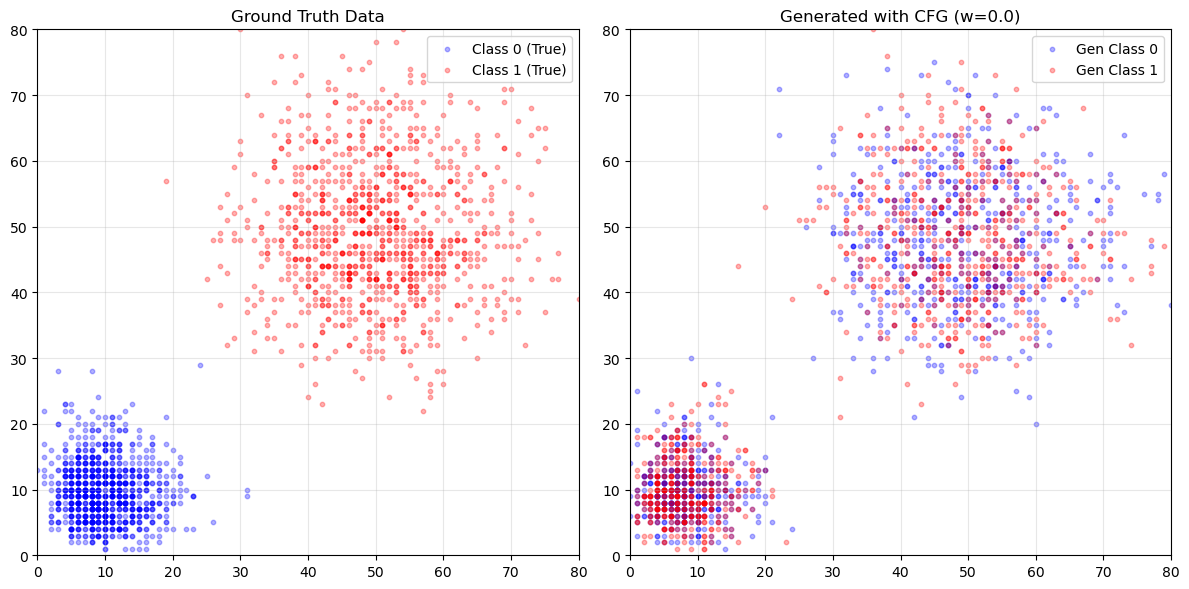

In [25]:
# Settings
guidance_scale = 0.0  # Try 1.0 (Normal) vs 2.0-4.0 (Guided)
n_step = 500

print(f"Generating with CFG Scale w={guidance_scale}...")

# Generate Class 0 (Blue)
gen_class_0 = sample_euler_cfg(model, n_step, X0_gen, class_label=0, 
                               guidance_scale=guidance_scale, device=device)

# Generate Class 1 (Red)
gen_class_1 = sample_euler_cfg(model, n_step, X0_gen, class_label=1, 
                               guidance_scale=guidance_scale, device=device)

# --- Visualization ---
plt.figure(figsize=(12, 6))

# Plot 1: Ground Truth (Reference)
plt.subplot(1, 2, 1)
plt.title("Ground Truth Data")
# Create dummy ground truth for viz
k0 = np.array([10.0, 10.0])
k1 = np.array([50.0, 50.0])
gt_0 = np.random.poisson(np.random.gamma(shape=k0, scale=1.0, size=(n_samples, 2)))
gt_1 = np.random.poisson(np.random.gamma(shape=k1, scale=1.0, size=(n_samples, 2)))

plt.scatter(gt_0[:,0], gt_0[:,1], c='blue', alpha=0.3, s=10, label='Class 0 (True)')
plt.scatter(gt_1[:,0], gt_1[:,1], c='red',  alpha=0.3, s=10, label='Class 1 (True)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 80); plt.ylim(0, 80)

# Plot 2: Generated with CFG
plt.subplot(1, 2, 2)
plt.title(f"Generated with CFG (w={guidance_scale})")
plt.scatter(gen_class_0[:,0], gen_class_0[:,1], c='blue', alpha=0.3, s=10, label='Gen Class 0')
plt.scatter(gen_class_1[:,0], gen_class_1[:,1], c='red',  alpha=0.3, s=10, label='Gen Class 1')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 80); plt.ylim(0, 80)

plt.tight_layout()
# plt.savefig('cfg_generation_results.png')
plt.show()

Generating with CFG Scale w=1.0...


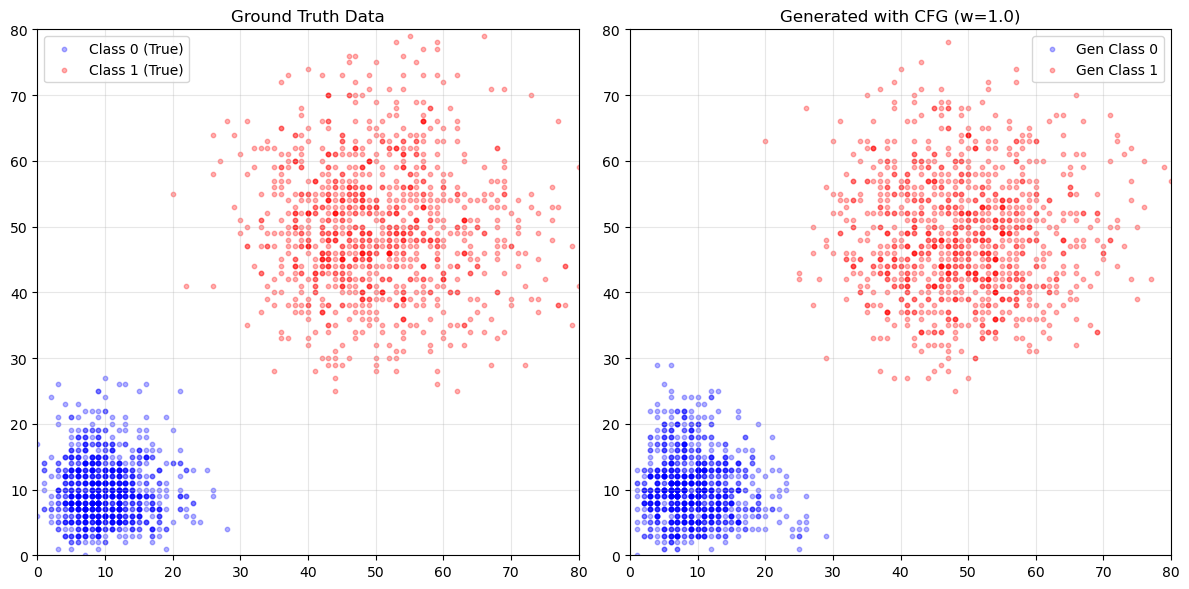

In [26]:
# Settings
guidance_scale = 1.0  # Try 1.0 (Normal) vs 2.0-4.0 (Guided)
n_step = 500

print(f"Generating with CFG Scale w={guidance_scale}...")

# Generate Class 0 (Blue)
gen_class_0 = sample_euler_cfg(model, n_step, X0_gen, class_label=0, 
                               guidance_scale=guidance_scale, device=device)

# Generate Class 1 (Red)
gen_class_1 = sample_euler_cfg(model, n_step, X0_gen, class_label=1, 
                               guidance_scale=guidance_scale, device=device)

# --- Visualization ---
plt.figure(figsize=(12, 6))

# Plot 1: Ground Truth (Reference)
plt.subplot(1, 2, 1)
plt.title("Ground Truth Data")
# Create dummy ground truth for viz
k0 = np.array([10.0, 10.0])
k1 = np.array([50.0, 50.0])
gt_0 = np.random.poisson(np.random.gamma(shape=k0, scale=1.0, size=(n_samples, 2)))
gt_1 = np.random.poisson(np.random.gamma(shape=k1, scale=1.0, size=(n_samples, 2)))

plt.scatter(gt_0[:,0], gt_0[:,1], c='blue', alpha=0.3, s=10, label='Class 0 (True)')
plt.scatter(gt_1[:,0], gt_1[:,1], c='red',  alpha=0.3, s=10, label='Class 1 (True)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 80); plt.ylim(0, 80)

# Plot 2: Generated with CFG
plt.subplot(1, 2, 2)
plt.title(f"Generated with CFG (w={guidance_scale})")
plt.scatter(gen_class_0[:,0], gen_class_0[:,1], c='blue', alpha=0.3, s=10, label='Gen Class 0')
plt.scatter(gen_class_1[:,0], gen_class_1[:,1], c='red',  alpha=0.3, s=10, label='Gen Class 1')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 80); plt.ylim(0, 80)

plt.tight_layout()
# plt.savefig('cfg_generation_results.png')
plt.show()

Generating with CFG Scale w=2.0...


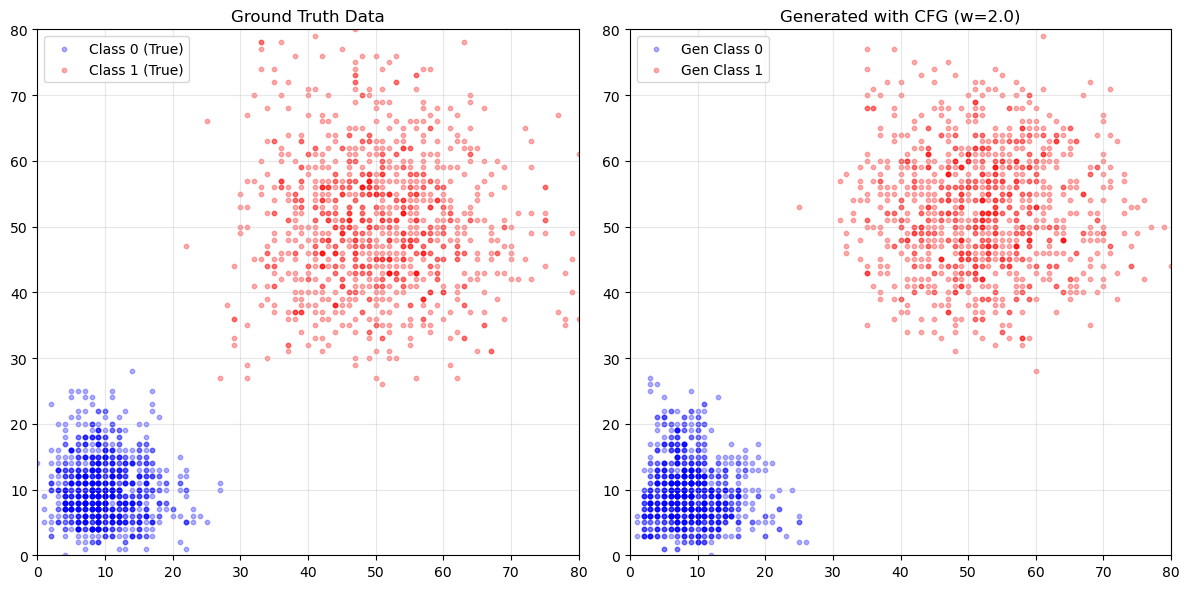

In [27]:
# Settings
guidance_scale = 2.0  # Try 1.0 (Normal) vs 2.0-4.0 (Guided)
n_step = 500

print(f"Generating with CFG Scale w={guidance_scale}...")

# Generate Class 0 (Blue)
gen_class_0 = sample_euler_cfg(model, n_step, X0_gen, class_label=0, 
                               guidance_scale=guidance_scale, device=device)

# Generate Class 1 (Red)
gen_class_1 = sample_euler_cfg(model, n_step, X0_gen, class_label=1, 
                               guidance_scale=guidance_scale, device=device)

# --- Visualization ---
plt.figure(figsize=(12, 6))

# Plot 1: Ground Truth (Reference)
plt.subplot(1, 2, 1)
plt.title("Ground Truth Data")
# Create dummy ground truth for viz
k0 = np.array([10.0, 10.0])
k1 = np.array([50.0, 50.0])
gt_0 = np.random.poisson(np.random.gamma(shape=k0, scale=1.0, size=(n_samples, 2)))
gt_1 = np.random.poisson(np.random.gamma(shape=k1, scale=1.0, size=(n_samples, 2)))

plt.scatter(gt_0[:,0], gt_0[:,1], c='blue', alpha=0.3, s=10, label='Class 0 (True)')
plt.scatter(gt_1[:,0], gt_1[:,1], c='red',  alpha=0.3, s=10, label='Class 1 (True)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 80); plt.ylim(0, 80)

# Plot 2: Generated with CFG
plt.subplot(1, 2, 2)
plt.title(f"Generated with CFG (w={guidance_scale})")
plt.scatter(gen_class_0[:,0], gen_class_0[:,1], c='blue', alpha=0.3, s=10, label='Gen Class 0')
plt.scatter(gen_class_1[:,0], gen_class_1[:,1], c='red',  alpha=0.3, s=10, label='Gen Class 1')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 80); plt.ylim(0, 80)

plt.tight_layout()
# plt.savefig('cfg_generation_results.png')
plt.show()

Generating with CFG Scale w=10.0...


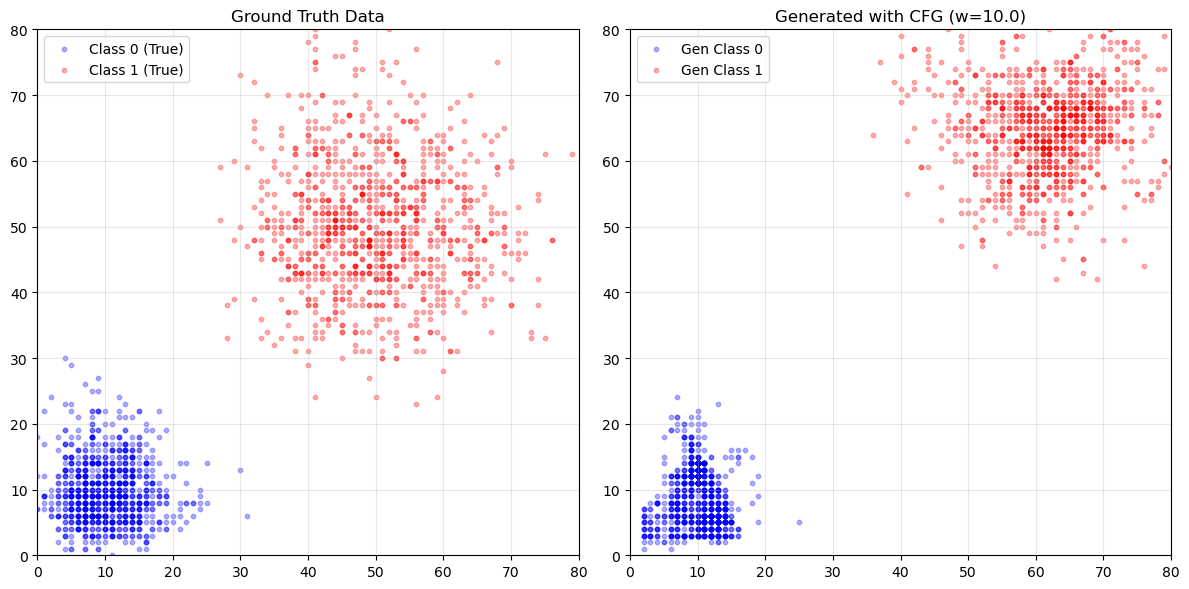

In [29]:
# Settings
guidance_scale = 10.0  # Try 1.0 (Normal) vs 2.0-4.0 (Guided)
n_step = 500

print(f"Generating with CFG Scale w={guidance_scale}...")

# Generate Class 0 (Blue)
gen_class_0 = sample_euler_cfg(model, n_step, X0_gen, class_label=0, 
                               guidance_scale=guidance_scale, device=device)

# Generate Class 1 (Red)
gen_class_1 = sample_euler_cfg(model, n_step, X0_gen, class_label=1, 
                               guidance_scale=guidance_scale, device=device)

# --- Visualization ---
plt.figure(figsize=(12, 6))

# Plot 1: Ground Truth (Reference)
plt.subplot(1, 2, 1)
plt.title("Ground Truth Data")
# Create dummy ground truth for viz
k0 = np.array([10.0, 10.0])
k1 = np.array([50.0, 50.0])
gt_0 = np.random.poisson(np.random.gamma(shape=k0, scale=1.0, size=(n_samples, 2)))
gt_1 = np.random.poisson(np.random.gamma(shape=k1, scale=1.0, size=(n_samples, 2)))

plt.scatter(gt_0[:,0], gt_0[:,1], c='blue', alpha=0.3, s=10, label='Class 0 (True)')
plt.scatter(gt_1[:,0], gt_1[:,1], c='red',  alpha=0.3, s=10, label='Class 1 (True)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 80); plt.ylim(0, 80)

# Plot 2: Generated with CFG
plt.subplot(1, 2, 2)
plt.title(f"Generated with CFG (w={guidance_scale})")
plt.scatter(gen_class_0[:,0], gen_class_0[:,1], c='blue', alpha=0.3, s=10, label='Gen Class 0')
plt.scatter(gen_class_1[:,0], gen_class_1[:,1], c='red',  alpha=0.3, s=10, label='Gen Class 1')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 80); plt.ylim(0, 80)

plt.tight_layout()
# plt.savefig('cfg_generation_results.png')
plt.show()